In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression

In [ ]:
# 1. Exploratory Data Analysis and Data Understanding


# NOTE: Replace 'unemployment_data.csv' with your actual file name
# For this example, we will create some dummy data to show how code works.
data = {
    'Year': np.arange(2000, 2021),
    'GDP_Growth': np.random.uniform(1, 5, 21),
    'Inflation_Rate': np.random.uniform(1, 10, 21),
    'Education_Level': np.random.uniform(50, 90, 21),
    'Unemployment_Rate': np.random.uniform(3, 12, 21) # This is our Target
}
df = pd.DataFrame(data)

In [ ]:
# Preview data
print("--- Data Preview ---")
print(df.head())

--- Data Preview ---
   Year  GDP_Growth  Inflation_Rate  Education_Level  Unemployment_Rate
0  2000    2.421613        8.953001        62.109172           9.420730
1  2001    2.300449        1.294519        67.054151           9.169974
2  2002    2.826338        5.921890        62.936792           7.589775
3  2003    1.295776        4.261247        53.721554          11.372795
4  2004    2.682721        5.885976        80.932309           5.754045


In [ ]:
# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Year                 0
GDP_Growth           0
Inflation_Rate       0
Education_Level      0
Unemployment_Rate    0
dtype: int64


In [ ]:
# Summary Statistics
print("\n--- Summary Statistics ---")
print(df.describe())


--- Summary Statistics ---
              Year  GDP_Growth  Inflation_Rate  Education_Level  \
count    21.000000   21.000000       21.000000        21.000000   
mean   2010.000000    3.227586        5.705991        71.422240   
std       6.204837    1.265063        2.781857        11.658446   
min    2000.000000    1.295776        1.032527        50.853021   
25%    2005.000000    2.421613        4.156431        63.169251   
50%    2010.000000    2.968793        5.871602        71.863300   
75%    2015.000000    4.392936        8.311151        80.932309   
max    2020.000000    4.976528        9.656935        89.521240   

       Unemployment_Rate  
count          21.000000  
mean            7.856253  
std             2.523955  
min             3.185078  
25%             5.754045  
50%             7.589775  
75%             9.497763  
max            11.372795  


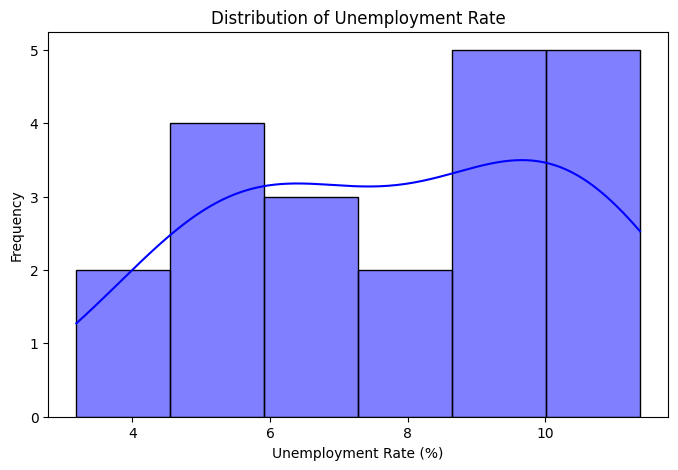

In [ ]:
# Visualization: Distribution of Target (Unemployment Rate)
plt.figure(figsize=(8, 5))
sns.histplot(df['Unemployment_Rate'], kde=True, color='blue')
plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.savefig('unemployment_dist.png')

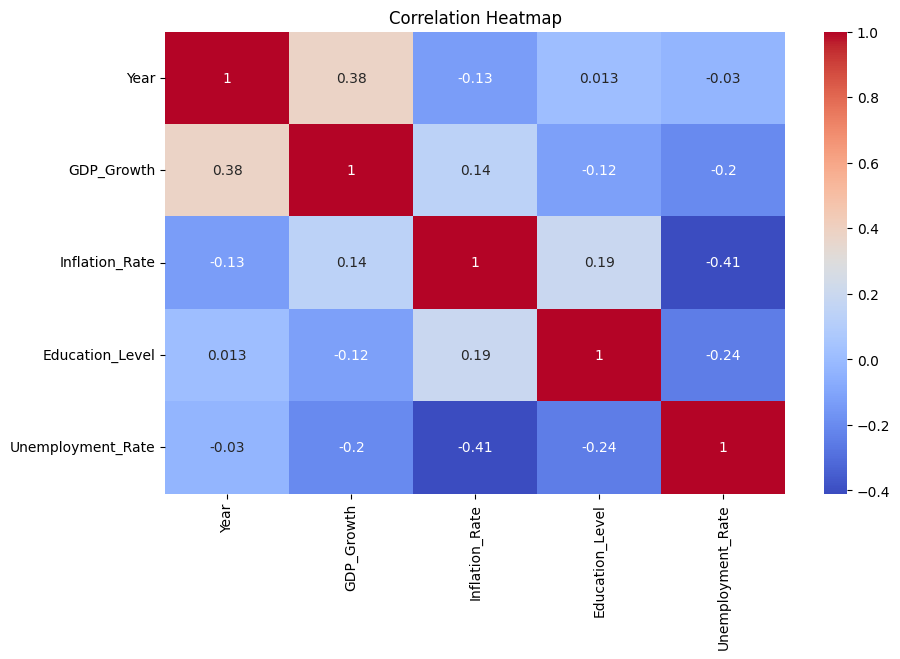

In [ ]:
# Visualization: Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

# 2. Data Preparation

In [ ]:
# Define Features (X) and Target (y)
X = df.drop('Unemployment_Rate', axis=1)
y = df['Unemployment_Rate']

In [ ]:
# Split into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scaling features (important for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#3. Task 1: Build a Neural Network Model


In [ ]:
# Designing the Multi-Layer Perceptron (MLP)
# Architecture: 2 hidden layers (64 neurons, 32 neurons)
nn_model = MLPRegressor(hidden_layer_sizes=(64, 32),
                        activation='relu',
                        solver='adam',
                        max_iter=1000,
                        random_state=42)

In [ ]:
# Training the model
nn_model.fit(X_train_scaled, y_train)

MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

In [ ]:
# Evaluation
nn_preds = nn_model.predict(X_test_scaled)
print("\n--- Neural Network Results ---")
print(f"MSE: {mean_squared_error(y_test, nn_preds):.2f}")
print(f"R-squared: {r2_score(y_test, nn_preds):.2f}")


--- Neural Network Results ---
MSE: 5.27
R-squared: -0.86


# 4. Task 2: Build Primary Classical ML Models

In [ ]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("\n--- Classical Model Initial Results ---")
print(f"Linear Regression R2: {r2_score(y_test, lr_preds):.2f}")
print(f"Random Forest R2: {r2_score(y_test, rf_preds):.2f}")


--- Classical Model Initial Results ---
Linear Regression R2: 0.25
Random Forest R2: -0.70


#5. Task 4: Hyper-parameter Optimization (Random Forest)

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           scoring='r2')
grid_search.fit(X_train, y_train)

best_rf_params = grid_search.best_params_
print("\n--- Best Parameters for Random Forest ---")
print(best_rf_params)
print(f"Best CV Score: {grid_search.best_score_:.2f}")


--- Best Parameters for Random Forest ---
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best CV Score: -1.07


# 6. Task 5: Feature Selection

In [ ]:
# Using SelectKBest to pick top features based on correlation
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train, y_train)

# Create a small summary of feature scores
feature_importance = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
feature_importance = feature_importance.sort_values(by='Score', ascending=False)
print("\n--- Feature Importance Scores ---")
print(feature_importance)


--- Feature Importance Scores ---
           Feature     Score
2   Inflation_Rate  2.817031
3  Education_Level  1.589904
0             Year  0.187326
1       GDP_Growth  0.046091


# 7. Task 6: Final Models and Comparison

In [ ]:
# Rebuild Models with Best Parameters
final_rf = RandomForestRegressor(**best_rf_params, random_state=42)
final_rf.fit(X_train, y_train)
final_rf_preds = final_rf.predict(X_test)

# Comparison Table Data
results_data = {
    'Model': ['Linear Regression', 'Random Forest (Final)'],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_preds)),
        np.sqrt(mean_squared_error(y_test, final_rf_preds))
    ],
    'Test R-squared': [
        r2_score(y_test, lr_preds),
        r2_score(y_test, final_rf_preds)
    ]
}

results_df = pd.DataFrame(results_data)
print("\n--- Final Model Comparison ---")
print(results_df)


--- Final Model Comparison ---
                   Model  Test RMSE  Test R-squared
0      Linear Regression   1.455603        0.252776
1  Random Forest (Final)   2.080596       -0.526652


In [ ]:
# Save results to CSV for your report
results_df.to_csv('regression_comparison_results.csv', index=False)